# TP1 : Algorithme EM et modèle de mélange gaussien

## G3 SDI - Introduction à l'Estimation Statistique

L'objectif de ce TP est d'implémenter l'algorithme EM pour estimer par maximum de vraisemblance les paramètres d'un modèle de mélange gaussien.

On utilisera le dataset *Old Faithful*, qui décrit 272 éruptions du geyser appelé Old Faithful du parc national de Yellowstone aux États-Unis. Chaque observation est constituée de 2 variables : la durée de l'éruption (en minutes) et le temps d'attente avant l'éruption (en minutes).

### Instructions

1. Renommez votre notebook sous la forme `tp1_Nom1_Nom2.ipynb`. 

2. Votre code et les résultats obtenus doivent être commentés !

3. Déposez votre notebook sur Moodle dans la section prévue à cet effet avant la date limite.

<div style="background-color: rgba(255, 255, 0, 0.15); padding: 8px;">
Compte-rendu écrit par [nom1], [nom2], date.
</div>

In [1]:
# Import necessary libraries
import numpy as np
from matplotlib import pyplot as plt
import scipy.stats as ss

**Q1**. Charger le dataset, normaliser puis visualiser les données. Commenter.

(272, 2)
Moyennes d'origine : [ 3.48778309 70.89705882]
Variances d'origine : [  1.29793889 184.14381488]
Corrélation durée / attente : 0.901


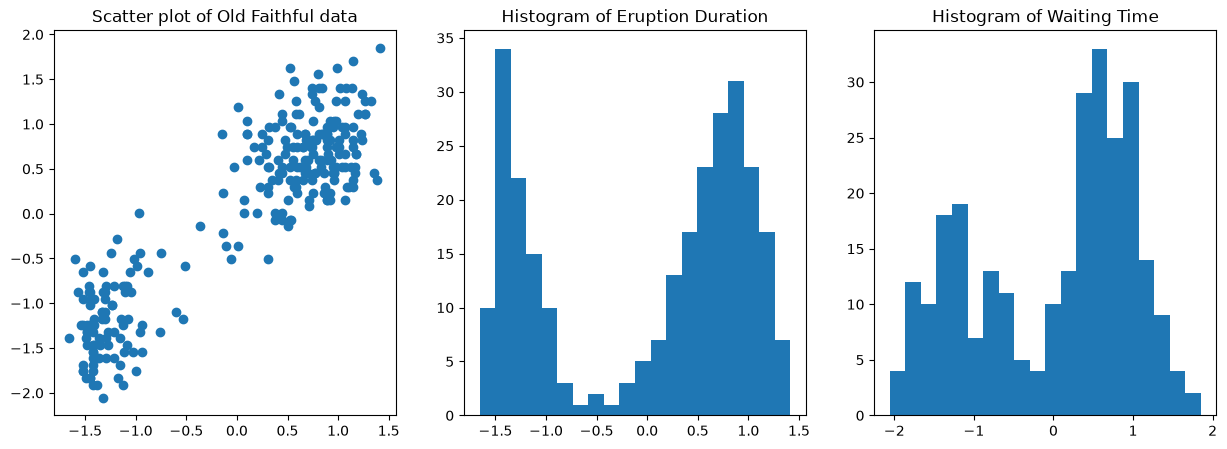

In [12]:
# Load the "Old Faithful" dataset from the archive

data = np.load("oldfaithful.npy")
print(data.shape)


# Standardize data to avoid numerical instabilities

from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
scaler.fit(data)
data = scaler.transform(data)
print("Moyennes d'origine :", scaler.mean_)
print("Variances d'origine :", scaler.var_)
print("Corrélation durée / attente :", np.corrcoef(data[:, 0], data[:, 1])[0, 1].round(3))


# Display data
fig, ax =  plt.subplots(1,3, figsize=(15, 5))
ax[0].scatter(data[:, 0], data[:, 1])
ax[1].hist(data[:, 0], bins=20)
ax[2].hist(data[:, 1], bins=20)
ax[0].set_title("Scatter plot of Old Faithful data")
ax[1].set_title("Histogram of Eruption Duration")
ax[2].set_title("Histogram of Waiting Time")
plt.show()


<div style="background-color: rgba(255, 255, 0, 0.15); padding: 8px;">
Chaque feature semble suivre une distribution correspondant à un somme de lois gaussiennes, de même pour le couple de features. La modélisation par un mélange gaussien à 2 composantes semble donc très pertinente ici.
Sur le nuage de points, on voit deux groupes : éruptions courtes précédées d'une attente courte, et éruptions longues précédées d'une attente longue. Les deux variables sont fortement corrélées.
</div>

**Q2**. On note $\mathbf{x}_1,...,\mathbf{x}_n$ les données. On souhaite les modéliser par un modèle de mélange gaussien à $K$ composantes.

Écrire une fonction permettant de calculer la log-vraisemblance :
$$ \log \mathcal{L}(\theta;\mathbf{x}_1,...,\mathbf{x}_n) = \sum_{i=1}^n \log \left( \sum_{k=1}^K \pi_k \frac{1}{2 \pi \text{det}(\boldsymbol{\Sigma}_k)^{1/2}} \exp \left( \frac{1}{2} (\mathbf{x}_i - \boldsymbol{\mu}_k)^{\top} \boldsymbol{\Sigma}_k^{-1} (\mathbf{x}_i - \boldsymbol{\mu}_k) \right) \right), $$
avec $\theta = \{ \boldsymbol{\mu_1}, ..., \boldsymbol{\mu_K}, \boldsymbol{\Sigma}_1, ..., \boldsymbol{\Sigma}_K, \pi_1, ..., \pi_K \}$.

On pourra utiliser la fonction `multivariate_normal.pdf` de la librairie scipy.stats.

In [3]:
from matplotlib.pylab import multivariate_normal


def log_likelihood(X, mu, cov, p):
    # X is the data, array of size N x 2
    # mu stores all the mu parameters, array of size K x 2
    # cov stores all the Sigma parameters, array of size K x 2 x 2
    # p stores all the pi parameters, array of size K
    K = len(p)
    a = np.zeros(X.shape[0])
    for k in range(K):
        a += p[k] * ss.multivariate_normal.pdf(X, mean=mu[k], cov=cov[k])
    return np.sum(np.log(a))


In [4]:
print(data.shape)
X = data
print(X.shape)
mu = np.array([[0, 0], [1, 1]])
cov = np.array([[[1, 0], [0, 1]], [[1, 0], [0, 1]]])
p = np.array([0.4, 0.6])

log_likelihood(X, mu, cov, p)

(272, 2)
(272, 2)


np.float64(-805.2227471944294)

**Q3**. Écrire une fonction qui implémente l'algorithme EM dans ce modèle, prenant pour arguments les données, le nombre de composantes $K$, et le nombre d'itérations de l'algorithme $N_{\text{iter}}$. Cette fonction retournera un tableau de taille $N_{\text{iter}} + 1$ contenant l'évolution des valeurs de la log-vraisemblance, ainsi que les valeurs finales des paramètres.

Initialisation des paramètres :
- Pour les moyennes, les $K$ premières observations du dataset ;
- Pour les matrices de covariances, la matrice identité ;
- $\pi_k = 1/K$ pour tout $k$.

In [5]:
#1ère version, pas vectorisée, on explicite toutes les boucles pour bien comprendre les étapes

def loop_EM_algorithm_v1(X, K, Niter):
    # Initialize parameters

    p = np.ones(K) / K
    mu = X[:K, :].copy() #K premières observations du dataset
    cov = np.array([np.eye(X.shape[1])] * K) # array de K matrice identité 2x2

    R = np.zeros((X.shape[0], K)) # array de taille N x K

    #initialisation du tableau en sortie :

    T = np.empty(Niter + 1, dtype=object) #object pour stocker des tuples de tailles différentes


    for i in range(0,Niter):
        # E-STEP
        for n in range(X.shape[0]):
            s = 0
            for k in range(K):
                R[n,k] = p[k] * ss.multivariate_normal.pdf(X[n, :], mean=mu[k], cov=cov[k])
                s += R[n,k] #terme de normalisation
            R[n,:] /= s

        # M-STEP

        for k in range(K):
            #terme de normalisation
            Nk = np.sum(R[:,k])

            #calcul de la moyenne
            mu[k] = 0
            for n in range(X.shape[0]):
                mu[k] += R[n,k] * X[n,:]
            mu[k] /= Nk

            #calcul de la covariance
            cov[k] = 0
            for n in range(X.shape[0]):
                diff = X[n,:] - mu[k]
                cov[k] += R[n,k] * np.outer(diff, diff)
            cov[k] /= Nk
            p[k] = Nk / X.shape[0]

        T[i] = log_likelihood(X, mu, cov, p)
    T[Niter] = (mu, cov, p)

    return T

# 2ème version vectorisée :

def EM_algorithm_v1(X, K, Niter):
    # Initialize parameters
    p = np.ones(K) / K
    mu = X[:K, :].copy()                            # K premières observations du dataset
    cov = np.array([np.eye(X.shape[1])] * K)        # K matrices identité

    R = np.zeros((X.shape[0], K))                   # array de taille N x K
    T = np.empty(Niter + 1, dtype=object)           # object pour stocker des tuples

    for i in range(Niter):
        # E-STEP
        for k in range(K):
            R[:, k] = p[k] * ss.multivariate_normal.pdf(X, mean=mu[k], cov=cov[k])
        R /= R.sum(axis=1, keepdims=True)# normalisation de chaque ligne

        # M-STEP
        for k in range(K):
            Nk = np.sum(R[:, k])

            mu[k] = R[:, k] @ X / Nk# calcul de la moyenne

            diff = X - mu[k]# calcul de la covariance
            cov[k] = (R[:, k, None] * diff).T @ diff / Nk

            p[k] = Nk / X.shape[0]

        T[i] = log_likelihood(X, mu, cov, p)
    T[Niter] = (mu, cov, p)

    return T


**Q4**. Faire tourner l'algorithme avec $K = 2$ et $N_{\text{iter}} = 50$.

Afficher l'évolution de la log-vraisemblance en fonction des itérations. Commenter.

Sur une même figure, afficher le dataset et représenter les estimations des deux lois normales du mélange à l'aide d'un *contour plot*. On pourra utiliser la fonction `plt.contour` (voir par exemple [ici](https://gist.github.com/gwgundersen/90dfa64ca29aa8c3833dbc6b03de44be)).

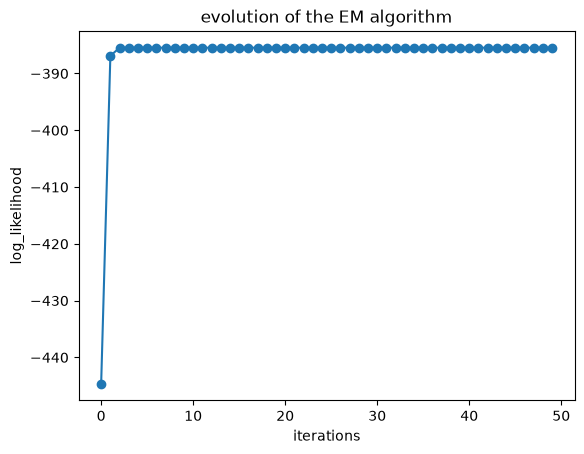

mu = [[ 0.7038525   0.66846596]
 [-1.27396762 -1.20991826]]
cov = [[[0.13095257 0.06084201]
  [0.06084201 0.19575032]]

 [[0.05329039 0.02814822]
  [0.02814822 0.18299437]]]
p = [0.64412714 0.35587286]
likelihood = -385.46069562977937


In [6]:
K = 2
Niter = 50

T = EM_algorithm_v1(X=X, K=K, Niter=Niter)

ll = np.array(T[:Niter], dtype=float)   # conversion object -> float pour le tracé
mu, cov, p = T[Niter]                   # paramètres finaux

plt.plot(np.arange(Niter), ll, "-o")
plt.xlabel("iterations")
plt.ylabel("log_likelihood")
plt.title("evolution of the EM algorithm")
plt.show()

print("mu =", mu)
print("cov =", cov)
print("p =", p)
print("likelihood =", T[Niter-1])

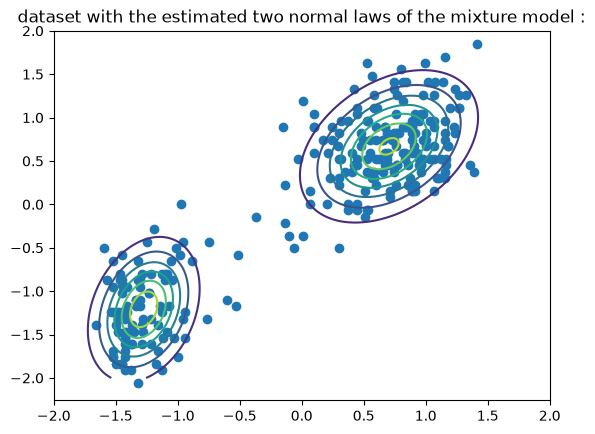

In [7]:
#D'après l'exemple fourni
N    = 500
X1   = np.linspace(-2, 2, N)
Y1    = np.linspace(-2, 2, N)
X1, Y1 = np.meshgrid(X1, Y1)
pos  = np.dstack((X1, Y1))
rv1   = ss.multivariate_normal(mu[0], cov[0])
Z1    = rv1.pdf(pos)
rv2   = ss.multivariate_normal(mu[1], cov[1])
Z2 = rv2.pdf(pos)
plt.scatter(data[:, 0], data[:, 1])
plt.contour(X1, Y1, Z1)
plt.contour(X1, Y1, Z2)
plt.title("dataset with the estimated two normal laws of the mixture model :")
plt.show()

<div style="background-color: rgba(255, 255, 0, 0.15); padding: 8px;">
La log-vraisemblance augmente à chaque itération et se stabilise à -385,46. La méthode a quasiment convergé en 3 itérations.
D'après la figure, chaque ellipse encadre bien un des deux nuages de points, et leur inclinaison suit la corrélation positive entre durée et attente.
</div>

**Q5**. On souhaite maintenant étudier l'influence de l'initialisation sur les résultats. Modifier la fonction implémentant l'algorithme EM en y rajoutant un argument pour la graine aléatoire. Les paramètres seront maintenant initialisés de la manière suivante :
- $\boldsymbol{\mu}_k \sim \mathcal{N}(\mathbf{0},\mathbf{I}_2)$ ;
- $[\pi_1, ..., \pi_K]^{\top} \sim \text{Dirichlet}([1, ..., 1]^{\top})$ ;
- On gardera l'initialisation des matrices de covariance à la matrice identité.

In [8]:
def EM_algorithm_v2(X, K, Niter, seed):
    # Initialize parameters
    rng = np.random.RandomState(seed)
    p = rng.dirichlet(np.ones(K))
    mu = rng.normal(size=(K, X.shape[1]))
    cov = np.array([np.eye(X.shape[1])] * K)

    R = np.zeros((X.shape[0], K))
    T = np.empty(Niter + 1, dtype=object)

    for i in range(Niter):
        # E-STEP
        for k in range(K):
            R[:, k] = p[k] * ss.multivariate_normal.pdf(X, mean=mu[k], cov=cov[k])
        R /= R.sum(axis=1, keepdims=True)

        # M-STEP
        for k in range(K):
            Nk = np.sum(R[:, k])
            mu[k] = R[:, k] @ X / Nk
            diff = X - mu[k]
            cov[k] = (R[:, k, None] * diff).T @ diff / Nk
            p[k] = Nk / X.shape[0]

        T[i] = log_likelihood(X, mu, cov, p)
    T[Niter] = (mu, cov, p)

    return T


**Q6**. On choisit maintenant $K=3$. Représenter l'évolution de la log-vraisemblance pour 10 graines aléatoires différentes. Commenter.

Afficher deux cas où la solution retournée par l'algorithme EM est visuellement différente. Commenter.

Quelle estimation de paramètres doit-on choisir ?

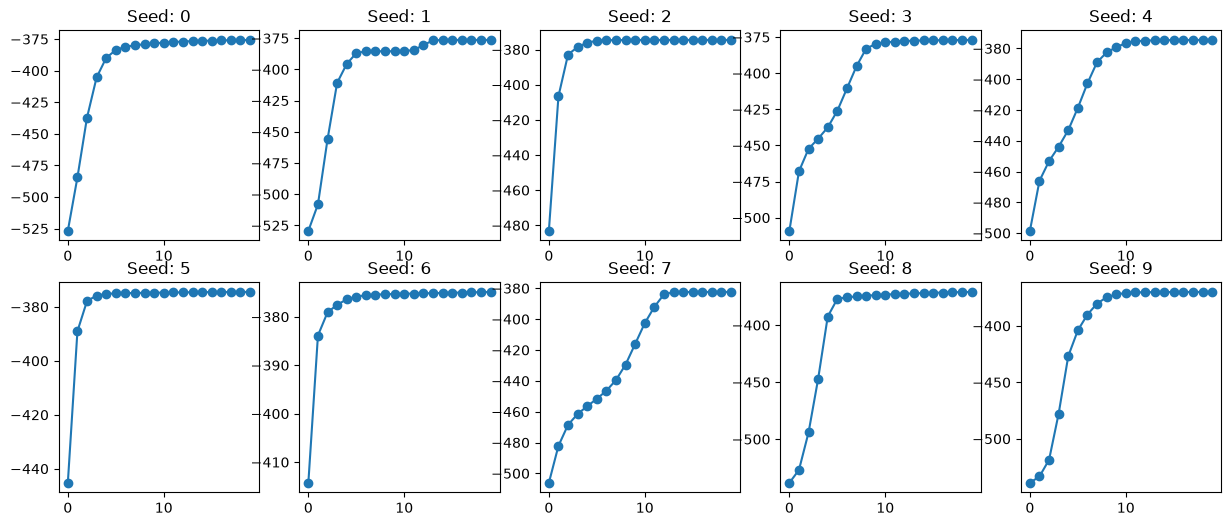

In [9]:
K = 3
Niter = 20
fig, ax = plt.subplots(2, 5, figsize=(15, 6))
llist = []
parameters_list = []
for seed in np.arange(10):
    ax[seed // 5, seed % 5].set_title(f"Seed: {seed}")
    T = EM_algorithm_v2(X=X, K=K, Niter=Niter, seed=seed)
    ll = np.array(T[:Niter], dtype=float)   # conversion object -> float pour le tracé
    mu, cov, p = T[Niter]
    llist.append(T[Niter-1])
    parameters_list.append((mu, cov, p))
    ax[seed // 5, seed % 5].plot(np.arange(Niter), ll, "-o")
plt.show()


In [10]:
print("moins bonne vraisemblance =", min(llist))
b = np.argmax(llist)
print("meilleure vraisemblance =" , max(llist))
print("meilleure approximation des paramètres : ", parameters_list[b])

moins bonne vraisemblance = -382.3420110006929
meilleure vraisemblance = -369.9328201644645
meilleure approximation des paramètres :  (array([[-1.43763042, -1.38191358],
       [ 0.70511052,  0.66969726],
       [-1.16123264, -1.09181052]]), array([[[ 0.00433701, -0.00257261],
        [-0.00257261,  0.1219289 ]],

       [[ 0.12958942,  0.05943101],
        [ 0.05943101,  0.19447006]],

       [[ 0.05736972,  0.0183351 ],
        [ 0.0183351 ,  0.19147822]]]), array([0.14347409, 0.64344467, 0.21308124]))


<div style="background-color: rgba(255, 255, 0, 0.15); padding: 8px;">
En choisissant des vecteurs générés aléatoirement pour l'initialisation, alors, selon l'expérience,  on obtient des résultats assez divers en vitesse de convergence, et surtout, en valeur limite, qui correspond à la valeur maximale de vraisemblance obtenue. Ainsi, selon les paramètres d'initialisation, les paramètres seront plus ou moins bien estimés ! Le choix de l'initialisation des paramètres est donc très important dans cette méthode : l'algorithme EM ne garantit qu'un maximum local de vraisemblance.


Pour un budget de Nmax = 20 itérations, la meilleure vraisemblance atteinte parmi toutes les seed testées est -369,93. 
</div>

**Q7**. On cherche maintenant à choisir la valeur optimale de $K$. Pour cela, on aimerait pouvoir comparer la vraisemblance des modèles obtenus avec différentes valeurs de $K$.

Cela peut se faire au travers d'un critère de sélection de modèle. Dans ce TP, nous étudierons le critère dit BIC :
$$ \text{BIC}(m) = k(m) \log(n) - 2 \log \mathcal{L}(m),$$
où $m$ est un modèle (ici donné par une valeur de $K$), $k(m)$ est le nombre de paramètres libres dans le modèle, $n$ le nombre d'échantillons, et $\mathcal{L}(m)$ le maximum de la fonction de vraisemblance du modèle $m$. On sélectionne le modèle avec le plus faible BIC.

Montrer que $$k(m) = \frac{K}{2} (D+1)(D+2) - 1.$$


**Preuve.** Comptons les paramètres libres d'un mélange de $K$ gaussiennes en dimension $D$ :

- **Moyennes** $\boldsymbol{\mu}_k \in \mathbb{R}^D$ : $D$ paramètres par composante, soit $KD$.
- 
- **Covariances** $\boldsymbol{\Sigma}_k$ : matrice $D \times D$ symétrique, donc déterminée par sa diagonale et son triangle supérieur, soit $D + \frac{D(D-1)}{2} = \frac{D(D+1)}{2}$ paramètres par composante, donc au total : $K\frac{D(D+1)}{2}$.

- **Poids** $\pi_1,\dots,\pi_K$ : $K$ valeurs soumises à la contrainte $\sum_k \pi_k = 1$, donc $K-1$ paramètres libres.

Au total :
$$k(m) = KD + K\frac{D(D+1)}{2} + K - 1 = \frac{K}{2}\left(2D + D(D+1) + 2\right) - 1 = \frac{K}{2}\left(D^2 + 3D + 2\right) - 1 = \frac{K}{2}(D+1)(D+2) - 1.$$
$\square$

Comparer les valeurs de $K$ allant de 1 à 6. Quel est le modèle optimal d'après le critère BIC ?

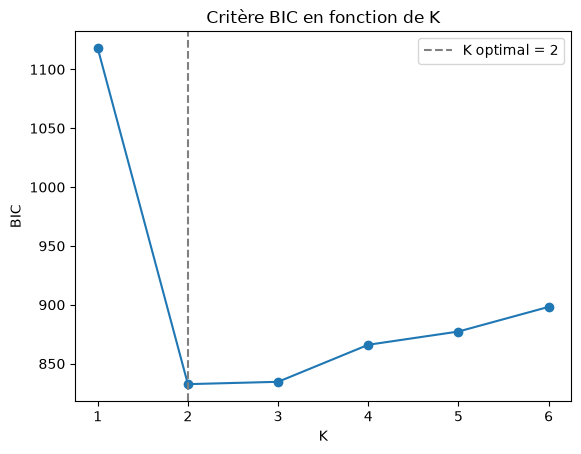

K = 1 : BIC = 1118.02
K = 2 : BIC = 832.59
K = 3 : BIC = 834.57
K = 4 : BIC = 866.03
K = 5 : BIC = 877.28
K = 6 : BIC = 898.22
K optimal : 2


In [11]:
def comparerK(X, K_list, Niter=50, n_seeds=10):
    n, D = X.shape
    BIC_list = []
    for K in K_list:
        # meilleure log-vraisemblance parmi n_seeds initialisations (T[Niter-1] = valeur finale)
        best_ll = max(float(EM_algorithm_v2(X, K, Niter, seed)[Niter - 1]) for seed in range(n_seeds))
        free = (K / 2) * (D + 1) * (D + 2) - 1 # nombre de paramètres libres
        BIC_list.append(free * np.log(n) - 2 * best_ll)

    K_best = K_list[int(np.argmin(BIC_list))]

    plt.plot(K_list, BIC_list, "-o")
    plt.axvline(K_best, color="gray", linestyle="--", label=f"K optimal = {K_best}")
    plt.xlabel("K")
    plt.ylabel("BIC")
    plt.title("Critère BIC en fonction de K")
    plt.legend()
    plt.show()

    return BIC_list, K_best

K_list = np.arange(1, 7)
BIC_list, K_best = comparerK(X, K_list)
for K, bic in zip(K_list, BIC_list):
    print(f"K = {K} : BIC = {bic:.2f}")
print("K optimal :", K_best)


<div style="background-color: rgba(255, 255, 0, 0.15); padding: 8px;">
On constate que, comme on pouvait s'y attendre d'après le plot des données, le meilleur modèle est un mélange à deux composantes gaussiennes : K_best = 2 
</div>

**Question bonus**. Expliquer comment le modèle de mélange gaussien peut être utilisé pour du clustering.

<div style="background-color: rgba(255, 255, 0, 0.15); padding: 8px;">
Tout "groupe" peut être vu comme un échantillon de points tous relativement proches d'un centre donné, et suffisamment éloignés d'autres centres. Donc un groupe peut être vu comme un échantillon généré par une loi normale avec un moyenne donnée et une dispersion donnée. Dès lors, "apprendre un groupe", c'est "apprendre une loi normale" suivie par un ensemble de points des données. Apprendre plusieurs groupes revient donc à estimer un certain nombre de lois normales avec une moyenne et une dispersion données, donc à apprendre l'ensemble des points comme une somme pondérée de plusieurs lois normales, ce qui est exactement un modèle de mélange gaussien.
</div>